# EDA реєстру корупційних правопорушень НАЗК

Ноутбук містить аналіз даних з `corrupt_all_data.json` (дамп API НАЗК): завантаження, перетворення у DataFrame, перевірка якості даних, розподіли за категоріями, географія, динаміка в часі та крос-аналіз для підготовки висновків і презентацій.

---

**Зміст**

1. **Підготовка та завантаження даних** — імпорти, завантаження JSON, формування DataFrame  
2. **Структура та якість даних** — нормалізація, пропуски, опис полів  
3. **Базовий опис та ключові показники** — розмір вибірки, заповненість ключових полів  
4. **Розподіли та категорії** — типи покарань, суб'єкти, види покарання (категорії), статті кодексу, регіони  
5. **Часовий аналіз** — динаміка вироків/постанов по роках  
6. **Крос-аналіз** — регіон × вид покарання (теплова карта, таблиці) 

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
sns.set(style="whitegrid", palette="muted")
plt.rcParams["figure.titlesize"] = 12
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["font.size"] = 10

## 1. Завантаження сирих даних з JSON

Очікується, що файл `corrupt_all_data.json` лежить у корені проєкту поруч із цим ноутбуком.

Кожен елемент списку — це запис з полями:

- ПІБ та атрибути фізичної особи (`indLastNameOnOffenseMoment`, ...),
- атрибути юрособи (якщо є),
- тип правопорушення, вид покарання, суд, статті кодексу тощо.

In [2]:
data_path = Path("corrupt_all_data.json")
assert data_path.exists(), f"Файл {data_path} не знайдено. Переконайся, що він лежить поруч із ноутбуком."

with data_path.open("r", encoding="utf-8") as f:
    raw_data = json.load(f)

len(raw_data)

28713

## 2. Формування `pandas DataFrame`

Базова структура — це список словників, тому можна напряму передати його у `DataFrame`.

Вкладені об'єкти (`punishmentType`, `entityType`, `codexArticles`) будемо частково нормалізувати окремо.

In [3]:
df = pd.DataFrame(raw_data)
df.head()

,id,punishmentType,entityType,indLastNameOnOffenseMoment,indFirstNameOnOffenseMoment,indPatronymicOnOffenseMoment,offenseId,offenseName,punishment,courtCaseNumber,sentenceDate,sentenceNumber,punishmentStart,courtId,courtName,codexArticles,addrPostIndex,addrCountryId,addrCountryName,addrStateId,addrStateName,addrStr,leShortNameOnOffenseMoment,leFullNameOnOffenseMoment,leRegistrationNumber,leLegalFormId,leLegalFormName,decreeDate,decreeNumber
0,80969,"{'code': 0, 'name': 'Судове рішення'}","{'code': 0, 'name': 'Фізична особа'}",Горечий,Олег,Романович,75786.0,"Прийняття пропозиції, обіцянки або одержання с...",Визнано винуватим у пред’явленому обвинуваченн...,297/383/19,2019-02-25,80200420,2019-03-28,660.0,Берегівський районний суд Закарпатської області,"[{'codexArticleId': 29, 'codexArticleName': 'П...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23,"{'code': 0, 'name': 'Судове рішення'}","{'code': 0, 'name': 'Фізична особа'}",Османова,Аліє,Сулейманівна,NaN,Дії Османової А.С. кваліфіковані за ч. 1 ст. 1...,NaN,3/0124/967/2012,2012-06-12,NaN,2012-06-26,19.0,Ялтинський міський суд Автономної Республіки Крим,"[{'codexArticleId': 18, 'codexArticleName': 'П...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,28,"{'code': 0, 'name': 'Судове рішення'}","{'code': 0, 'name': 'Фізична особа'}",Савченко,Валентин,Миколайович,NaN,"Савченко В.М., являючись службовою особою скл...",-,NaN,2011-10-31,1-177/11,2013-01-16,24.0,Октябрський районний суд м. Полтави,"[{'codexArticleId': 29, 'codexArticleName': 'П...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,38,"{'code': 0, 'name': 'Судове рішення'}","{'code': 0, 'name': 'Фізична особа'}",Бойчук,Наталія,Петрівна,NaN,"Привласнення та розтрата чужого майна, вчинена...",-,NaN,2011-10-17,1-167/11,2011-11-02,35.0,Чортківський районний суд Тернопільської області,"[{'codexArticleId': 29, 'codexArticleName': 'П...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,29729,"{'code': 0, 'name': 'Судове рішення'}","{'code': 0, 'name': 'Фізична особа'}",Ганущак,Марія,Володимирівна,NaN,пропозиція або надання службовій особі неправо...,NaN,3-5697/11,2011-11-10,54134511,2011-11-21,3107.0,Тернопільський міськрайонний суд Тернопільсько...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Нормалізація DataFrame: обрізати пробіли в рядках, порожні рядки -> NaN
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)
    df[col] = df[col].replace("", np.nan)

# Записи, де courtName порожнє (NaN або відсутнє)
empty_court = df["courtName"].isna()
n_empty = empty_court.sum()
print(f"Записів з порожнім courtName: {n_empty} з {len(df)}")
if n_empty > 0:
    display(df.loc[empty_court].head(50))

Записів з порожнім courtName: 2946 з 28713


,id,punishmentType,entityType,indLastNameOnOffenseMoment,indFirstNameOnOffenseMoment,indPatronymicOnOffenseMoment,offenseId,offenseName,punishment,courtCaseNumber,sentenceDate,sentenceNumber,punishmentStart,courtId,courtName,codexArticles,addrPostIndex,addrCountryId,addrCountryName,addrStateId,addrStateName,addrStr,leShortNameOnOffenseMoment,leFullNameOnOffenseMoment,leRegistrationNumber,leLegalFormId,leLegalFormName,decreeDate,decreeNumber
22360,381976,"{'code': 0, 'name': 'Судове рішення'}","{'code': 0, 'name': 'Фізична особа'}",Кастравець,Сергій,Юрійович,NaN,NaN,NaN,947/13835/24,2024-05-27,NaN,2024-06-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23107,425713,"{'code': 0, 'name': 'Судове рішення'}","{'code': 0, 'name': 'Фізична особа'}",Дячук,Тетяна,Йосипівна,NaN,NaN,NaN,NaN,2025-01-08,716/34/25,2025-01-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25769,70972,"{'code': 1, 'name': 'Дисциплінарне стягнення'}","{'code': 0, 'name': 'Фізична особа'}",Стрижкова,Інна,Іванівна,NaN,адміністративне правопорушення,Звільнення,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013-04-23,95-к
25770,70975,"{'code': 1, 'name': 'Дисциплінарне стягнення'}","{'code': 0, 'name': 'Фізична особа'}",Браташ,Сергій,Володимирович,NaN,вимагання та отримання незаконної матеріальної...,Інше стягнення,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2012-02-22,17 о/с
25771,70978,"{'code': 1, 'name': 'Дисциплінарне стягнення'}","{'code': 0, 'name': 'Фізична особа'}",Поршнєв,Анатолій,Володимирович,NaN,вимагання та отримання незаконної матеріальної...,Інше стягнення,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2012-02-15,15 о/с
25772,70981,"{'code': 1, 'name': 'Дисциплінарне стягнення'}","{'code': 0, 'name': 'Фізична особа'}",Вовк,Євгеній,Віталійович,NaN,Зловживання службовим становищем,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013-01-17,02-к
25773,70984,"{'code': 1, 'name': 'Дисциплінарне стягнення'}","{'code': 0, 'name': 'Фізична особа'}",Москаленко,Юрій,Віталійович,NaN,"Порушення п. 1 ст. 6 Закону України ""Про засад...",Звільнення,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2012-10-15,№ 1824/к
25774,71089,"{'code': 1, 'name': 'Дисциплінарне стягнення'}","{'code': 0, 'name': 'Фізична особа'}",Драниш,Валерій,Вікторович,NaN,одержання неправомірної вигоди (Порушення обме...,Звільнення,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2012-12-14,1922
25775,70987,"{'code': 1, 'name': 'Дисциплінарне стягнення'}","{'code': 0, 'name': 'Фізична особа'}",Матющенко,Денис,Миколайович,NaN,Перевищення влади або службових повноважень,Звільнення,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-11-01,458 о/с
25776,70992,"{'code': 1, 'name': 'Дисциплінарне стягнення'}","{'code': 0, 'name': 'Фізична особа'}",Авдєєв,Денис,Сергійович,NaN,Перевищення влади або службових повноважень,Звільнення,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010-11-01,458 о/с


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28713 entries, 0 to 28712
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            28713 non-null  int64  
 1   punishmentType                28713 non-null  object 
 2   entityType                    28713 non-null  object 
 3   indLastNameOnOffenseMoment    28698 non-null  object 
 4   indFirstNameOnOffenseMoment   28698 non-null  object 
 5   indPatronymicOnOffenseMoment  28584 non-null  object 
 6   offenseId                     19846 non-null  float64
 7   offenseName                   28707 non-null  object 
 8   punishment                    24776 non-null  object 
 9   courtCaseNumber               24424 non-null  object 
 10  sentenceDate                  25769 non-null  object 
 11  sentenceNumber                21456 non-null  object 
 12  punishmentStart               25485 non-null  object 
 13  c

**Опис полів (довідник):** для кожного стовпця — що означає заповнене значення та що може означати порожнє — див. файл **`DATA_DICTIONARY.md`** у папці проєкту.

### 2.1. Нормалізація вкладених полів

Виділимо кілька корисних полів із вкладених об'єктів:

- `punishmentType.code`, `punishmentType.name`,
- `entityType.code`, `entityType.name`,
- з `codexArticles` візьмемо першу статтю (якщо їх декілька) для спрощеного аналізу.

Також сформуємо зручне поле `full_name` для ПІБ.

In [6]:
# ПІБ
df["indLastNameOnOffenseMoment"] = df["indLastNameOnOffenseMoment"].astype("string")
df["indFirstNameOnOffenseMoment"] = df["indFirstNameOnOffenseMoment"].astype("string")
df["indPatronymicOnOffenseMoment"] = df["indPatronymicOnOffenseMoment"].astype("string")

df["full_name"] = (
    df["indLastNameOnOffenseMoment"].fillna("")
    + " "
    + df["indFirstNameOnOffenseMoment"].fillna("")
    + " "
    + df["indPatronymicOnOffenseMoment"].fillna("")
).str.strip()

# Тип покарання
df["punishmentType_code"] = df["punishmentType"].apply(lambda x: x.get("code") if isinstance(x, dict) else np.nan)
df["punishmentType_name"] = df["punishmentType"].apply(lambda x: x.get("name") if isinstance(x, dict) else np.nan)

# Тип суб'єкта (фіз./юр. особа)
df["entityType_code"] = df["entityType"].apply(lambda x: x.get("code") if isinstance(x, dict) else np.nan)
df["entityType_name"] = df["entityType"].apply(lambda x: x.get("name") if isinstance(x, dict) else np.nan)

# Усі статті кодексу для кожного запису (щоб рахувати всі, якщо у однієї особи кілька статей)
def extract_all_articles(articles):
    if not isinstance(articles, list):
        return []
    names = []
    for item in articles:
        if isinstance(item, dict):
            name = item.get("codexArticleName")
            if name:
                names.append(name)
    return names

df["codex_article_names"] = df["codexArticles"].apply(extract_all_articles)
# Для зворотної сумісності: перша стаття
df["first_codex_article"] = df["codex_article_names"].apply(lambda lst: lst[0] if lst else None)

df[[
    "id",
    "full_name",
    "punishmentType_name",
    "entityType_name",
    "offenseName",
    "first_codex_article",
]].head()

,id,full_name,punishmentType_name,entityType_name,offenseName,first_codex_article
0,80969,Горечий Олег Романович,Судове рішення,Фізична особа,"Прийняття пропозиції, обіцянки або одержання с...","Прийняття пропозиції, обіцянки або одержання н..."
1,23,Османова Аліє Сулейманівна,Судове рішення,Фізична особа,Дії Османової А.С. кваліфіковані за ч. 1 ст. 1...,Порушення вимог фінансового контролю
2,28,Савченко Валентин Миколайович,Судове рішення,Фізична особа,"Савченко В.М., являючись службовою особою скл...","Прийняття пропозиції, обіцянки або одержання н..."
3,38,Бойчук Наталія Петрівна,Судове рішення,Фізична особа,"Привласнення та розтрата чужого майна, вчинена...","Прийняття пропозиції, обіцянки або одержання н..."
4,29729,Ганущак Марія Володимирівна,Судове рішення,Фізична особа,пропозиція або надання службовій особі неправо...,None


## 3. Базовий опис даних

- розмірність,
- кількість пропусків,
- числові розподіли,
- приклади записів.

In [7]:
df.shape

(28713, 36)

In [8]:
df.isna().mean().sort_values(ascending=False).head(20)

addrStateId                   0.999965
addrCountryName               0.999965
addrCountryId                 0.999965
addrPostIndex                 0.999965
leLegalFormId                 0.999965
leLegalFormName               0.999965
leRegistrationNumber          0.999965
addrStateName                 0.999965
leFullNameOnOffenseMoment     0.999965
leShortNameOnOffenseMoment    0.999965
addrStr                       0.999965
decreeDate                    0.897503
decreeNumber                  0.897468
offenseId                     0.308815
sentenceNumber                0.252743
courtCaseNumber               0.149375
punishment                    0.137116
punishmentStart               0.112423
first_codex_article           0.104622
codexArticles                 0.104552
dtype: float64

In [9]:
numeric_cols = df.select_dtypes(include=["number"]).columns
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
id,28713.0,215647.696270,185963.288978,16.0,33695.0,129463.0,394137.0,524418.0
offenseId,19846.0,86857.207498,45338.170729,73942.0,74002.0,74103.0,76569.0,481694.0
courtId,25767.0,18721.182171,59706.000999,1.0,1495.0,4044.0,13821.0,502633.0
addrCountryId,1.0,141.000000,NaN,141.0,141.0,141.0,141.0,141.0
addrStateId,1.0,139968.000000,NaN,139968.0,139968.0,139968.0,139968.0,139968.0
leLegalFormId,1.0,73412.000000,NaN,73412.0,73412.0,73412.0,73412.0,73412.0
punishmentType_code,28713.0,0.102532,0.303352,0.0,0.0,0.0,0.0,1.0
entityType_code,28713.0,0.000035,0.005901,0.0,0.0,0.0,0.0,1.0


### 3.1. Ключові показники

Кількість записів і заповненість основних полів (до аналізу регіонів і категорій).

In [10]:
n_total = len(df)
n_punishment = df["punishment"].apply(lambda x: x is not None and str(x).strip() != "").sum()
n_court = df["courtName"].notna().sum()
n_sentence = df["sentenceDate"].notna().sum()
n_offense = df["offenseName"].notna().sum()
n_pib = (df["full_name"].notna() & (df["full_name"].astype(str).str.strip() != "")).sum()
print(f"Усього записів: {n_total:,}")
print(f"Заповнено текст покарання (punishment): {n_punishment:,} ({100*n_punishment/n_total:.1f}%)")
print(f"Заповнено назву суду (courtName): {n_court:,} ({100*n_court/n_total:.1f}%)")
print(f"Заповнено дату вироку (sentenceDate): {n_sentence:,} ({100*n_sentence/n_total:.1f}%)")
print(f"Заповнено назву правопорушення (offenseName): {n_offense:,} ({100*n_offense/n_total:.1f}%)")
print(f"Заповнено ПІБ (full_name): {n_pib:,} ({100*n_pib/n_total:.1f}%)")

Усього записів: 28,713
Заповнено текст покарання (punishment): 28,713 (100.0%)
Заповнено назву суду (courtName): 25,767 (89.7%)
Заповнено дату вироку (sentenceDate): 25,769 (89.7%)
Заповнено назву правопорушення (offenseName): 28,707 (100.0%)
Заповнено ПІБ (full_name): 28,698 (99.9%)


## 4. Розподіли та категорії

Нижче: типи покарань (punishmentType), тип суб'єкта (фіз/юр особа), види покарання за правилами з `punishment_categories`, статті кодексу, регіони. Для кожної групи — стовпчикові та кругові діаграми.

### 4.1. Типи покарань

Подивимося, як часто зустрічаються різні типи покарань (`punishmentType_name`).

In [11]:
punishment_counts = (
    df["punishmentType_name"]
    .fillna("(невідомо)")
    .value_counts()
)
punishment_counts.head(10)

punishmentType_name
Судове рішення             25769
Дисциплінарне стягнення     2944
Name: count, dtype: int64

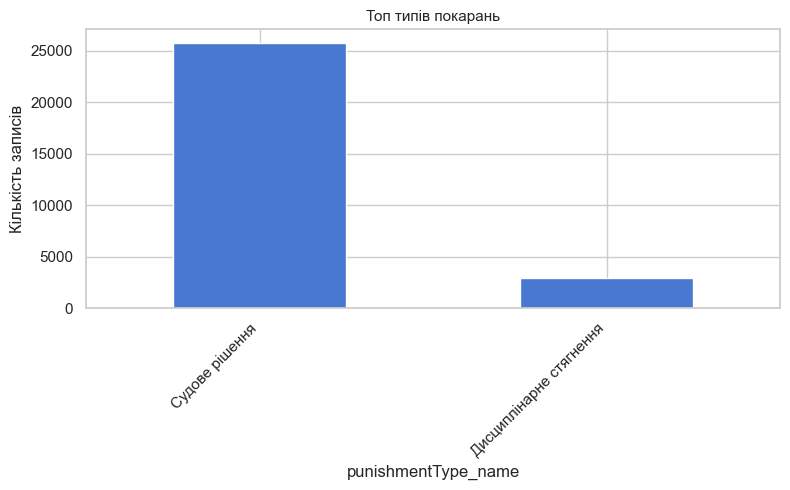

In [12]:
plt.figure(figsize=(8, 5))
punishment_counts.head(10).plot(kind="bar")
plt.title("Топ типів покарань")
plt.ylabel("Кількість записів")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 4.2. Тип суб'єкта (фізична/юридична особа)

Вивчимо розподіл фізичних та юридичних осіб у реєстрі.

In [13]:
entity_counts = df["entityType_name"].fillna("(невідомо)").value_counts()
entity_counts

entityType_name
Фізична особа     28712
Юридична особа        1
Name: count, dtype: int64

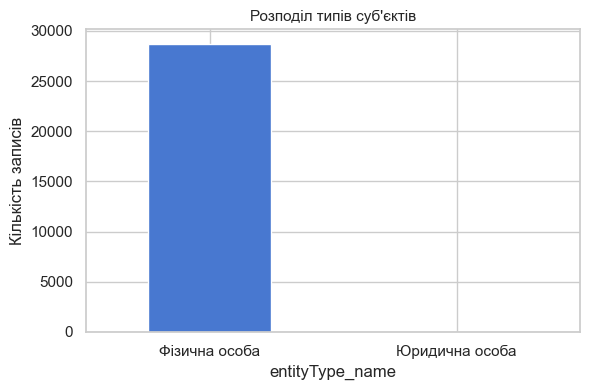

In [14]:
plt.figure(figsize=(6, 4))
entity_counts.plot(kind="bar")
plt.title("Розподіл типів суб'єктів")
plt.ylabel("Кількість записів")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

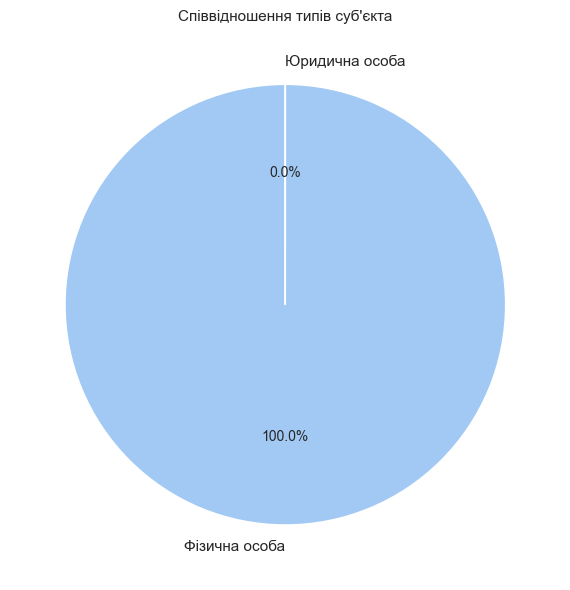

In [15]:
# Кругова діаграма: тип суб'єкта (фіз/юр особа); entity_counts — з попередньої клітинки
fig, ax = plt.subplots(figsize=(6, 6))
colors = sns.color_palette("pastel", len(entity_counts))
ax.pie(entity_counts, labels=entity_counts.index, autopct="%1.1f%%", startangle=90, colors=colors)
ax.set_title("Співвідношення типів суб'єкта")
plt.tight_layout()
plt.show()

### 4.2.1. Статистика за видами покарання (категорії з punishment_categories)

Правила категоризації такі самі, як у `export_punishment_list.py` (модуль `punishment_categories.py`): Догана, Сувора догана, Звільнення, Попередження, Відсутні, Штраф, Зауваження, Позбавлення волі, Без розгляду, Громадські роботи, Інше. Для записів без тексту покарання — «Невідомо (дата покар. відсутня)» або «Невідомо (дата покар. присутня)» залежно від наявності `punishmentStart`.

In [16]:
# Види покарання за правилами punishment_categories.py + обробка порожнього тексту
from punishment_categories import punishment_category

def punishment_status_row(row):
    """Повертає категорію покарання для рядка: з тексту punishment або «Невідомо» за наявності punishmentStart."""
    text = row.get("punishment")
    if text is None or (isinstance(text, str) and not text.strip()):
        has_start = pd.notna(row.get("punishmentStart")) and str(row.get("punishmentStart", "")).strip() != ""
        return "Невідомо (дата покар. відсутня)" if not has_start else "Невідомо (дата покар. присутня)"
    return punishment_category(str(text))

df["punishment_status"] = df.apply(punishment_status_row, axis=1)
punishment_status_counts = df["punishment_status"].value_counts()
punishment_status_counts

punishment_status
Штраф                16229
Інше                  4320
Позбавлення волі      3748
Відсутні              1529
Догана                1305
Звільнення             840
Зауваження             310
Громадські роботи      237
Попередження           115
Сувора догана           69
Без розгляду            11
Name: count, dtype: int64

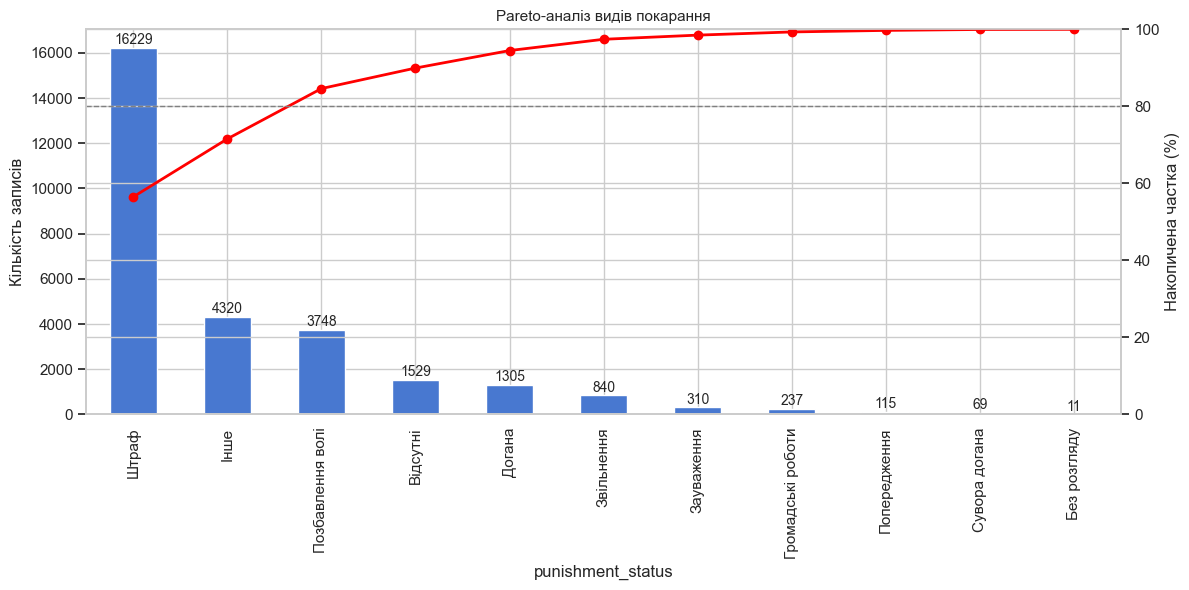

In [17]:
ps = punishment_status_counts.sort_values(ascending=False)
cum_percent = ps.cumsum() / ps.sum() * 100
fig, ax1 = plt.subplots(figsize=(12,6))
ps.plot(kind="bar", ax=ax1)
ax1.set_ylabel("Кількість записів")
ax1.set_title("Pareto-аналіз видів покарання")
for i, v in enumerate(ps):
    ax1.text(i, v + ps.max()*0.01, str(v), ha="center")
ax2 = ax1.twinx()

ax2.plot(
    range(len(cum_percent)),
    cum_percent,
    color="red",
    marker="o",
    linewidth=2
)
ax2.set_ylabel("Накопичена частка (%)")
ax2.set_ylim(0,100)
ax2.axhline(80, color="gray", linestyle="--", linewidth=1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

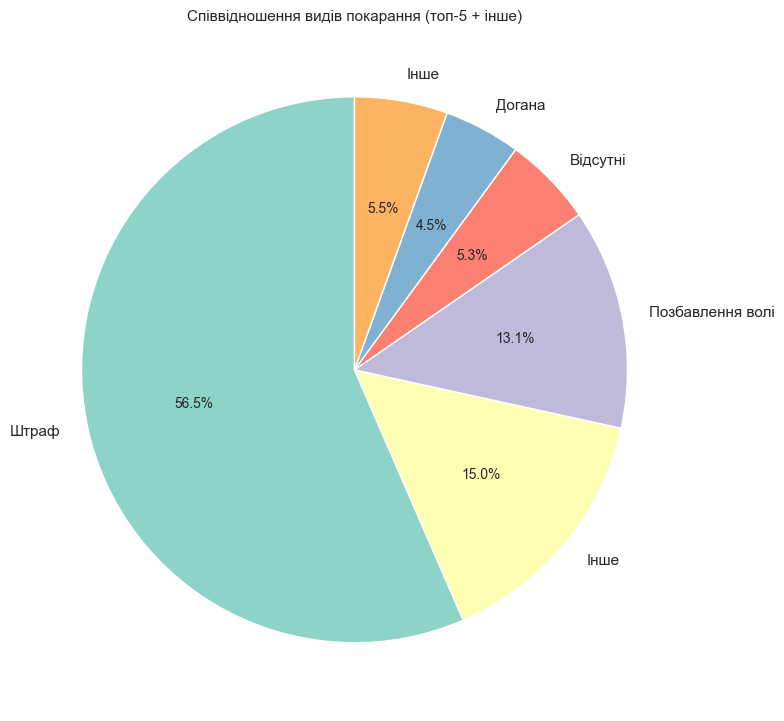

In [18]:
# Топ-5 + "Інше"
ps = punishment_status_counts.copy()

top5 = ps.nlargest(5)
other = ps.drop(top5.index).sum()

ps_final = pd.concat([top5, pd.Series({"Інше": other})])

# Побудова графіка
fig, ax = plt.subplots(figsize=(8, 8))

colors = sns.color_palette("Set3", len(ps_final))

ax.pie(
    ps_final,
    labels=ps_final.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors
)

ax.set_title("Співвідношення видів покарання (топ-5 + інше)")

plt.tight_layout()
plt.show()

### 4.3. Статті кодексу

Найчастіше вживані статті. Якщо в однієї особи кілька статей — рахується кожна окремо (`codex_article_names`, explode).

In [19]:
# Рахуємо кожну статтю окремо: якщо в однієї особи кілька статей — усі входять у підрахунок
article_counts = df["codex_article_names"].explode().fillna("(невідомо)").value_counts()
article_counts.head(15)

codex_article_names
Пропозиція, обіцянка або надання неправомірної вигоди службовій особі                                                      7435
Порушення вимог фінансового контролю                                                                                       5157
Прийняття пропозиції, обіцянки або одержання неправомірної вигоди службовою особою                                         3351
Привласнення, розтрата майна або заволодіння ним шляхом зловживання службовим становищем                                   3010
(невідомо)                                                                                                                 3004
Службове підроблення (порушення не є корупційним)                                                                          1758
Зловживання впливом                                                                                                        1552
Зловживання владою або службовим становищем                                         

In [20]:
# Регіон по courtName: довідник court_region_mapping.json (без парсингу з нуля), потім — парсинг лише для невідомих
from pathlib import Path
from regions import extract_region_from_court, lookup_region_from_known

# Завантажуємо готовий довідник суд -> область
mapping_path = Path("court_region_mapping.json")
assert mapping_path.exists(), f"Файл {mapping_path} не знайдено. Поклади його поруч із ноутбуком."
with mapping_path.open("r", encoding="utf-8") as f:
    known_court_to_region = json.load(f)

# Фаза 1: для кожного суду — регіон з довідника (точний або підрядковий збіг)
df["region_parsed"] = df["courtName"].apply(lambda c: lookup_region_from_known(c, known_court_to_region))

# Фаза 2: для тих, кого нема в довіднику — парсинг за правилами (regions.py)
still_unknown = df["region_parsed"].isna()
df.loc[still_unknown, "region_parsed"] = (
    df.loc[still_unknown, "courtName"].apply(extract_region_from_court)
)

df["region_clean"] = df["region_parsed"].fillna("(невідомо)")

total = len(df)
known = df["region_parsed"].notna().sum()
unknown = total - known
print(f"Загальна кількість записів: {total}")
print(f"Розпізнано регіон: {known} ({known/total:.1%})")
print(f"Нерозпізнано (невідомо): {unknown} ({unknown/total:.1%})")
print("\nТоп 20 регіонів (region_clean):")
print(df["region_clean"].value_counts().head(20))

unknown_mask = df["region_parsed"].isna()
unknown_sample = df.loc[unknown_mask, ["courtName", "addrStateName"]].drop_duplicates("courtName").head(25)
print("\nПриклади courtName з нерозпізнаним регіоном:")
print(unknown_sample.to_string())

Загальна кількість записів: 28713
Розпізнано регіон: 25767 (89.7%)
Нерозпізнано (невідомо): 2946 (10.3%)

Топ 20 регіонів (region_clean):
region_clean
(невідомо)                   2946
Дніпропетровська область     1913
Львівська область            1746
Київська область             1537
Харківська область           1395
Вінницька область            1328
Тернопільська область        1218
Одеська область              1182
Сумська область              1155
Волинська область            1095
Донецька область             1055
Чернівецька область          1022
Чернігівська область          991
Полтавська область            934
Івано-Франківська область     917
м. Київ                       905
Закарпатська область          899
Рівненська область            855
Хмельницька область           749
Запорізька область            729
Name: count, dtype: int64

Приклади courtName з нерозпізнаним регіоном:
      courtName addrStateName
22360       NaN           NaN


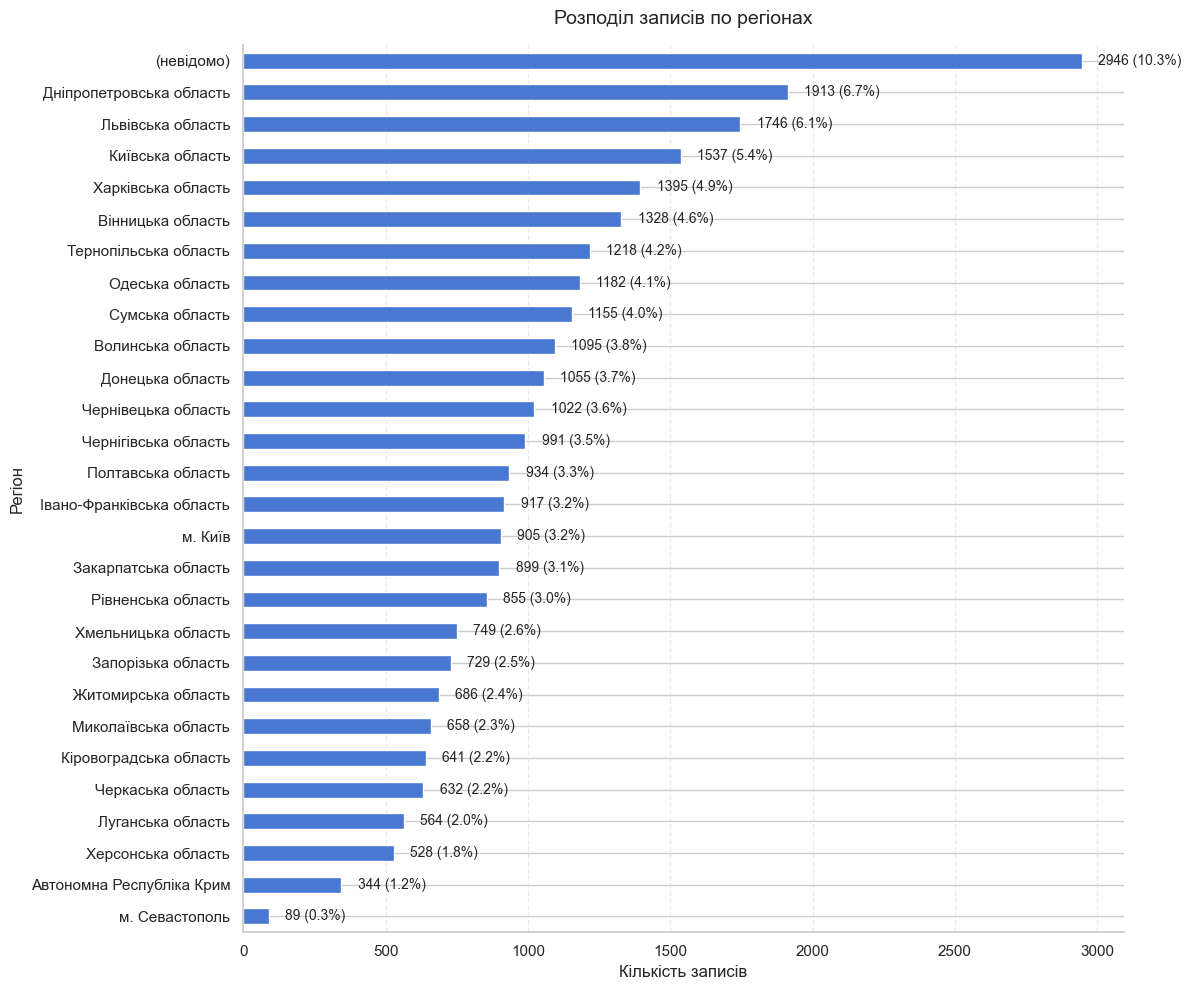

In [21]:
# Дані (всі регіони)
state_counts = df["region_clean"].value_counts().sort_values()

# загальна кількість
total = state_counts.sum()

fig, ax = plt.subplots(figsize=(12, 10))

state_counts.plot(kind="barh", ax=ax)

ax.set_title("Розподіл записів по регіонах", fontsize=14, pad=15)
ax.set_xlabel("Кількість записів")
ax.set_ylabel("Регіон")

# легка сітка
ax.grid(axis="x", linestyle="--", alpha=0.4)

# прибрати зайві рамки
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# підпис: кількість + частка
for i, v in enumerate(state_counts):
    percent = v / total * 100
    ax.text(v + total*0.002, i, f"{v} ({percent:.1f}%)", va="center")

plt.tight_layout()
plt.show()

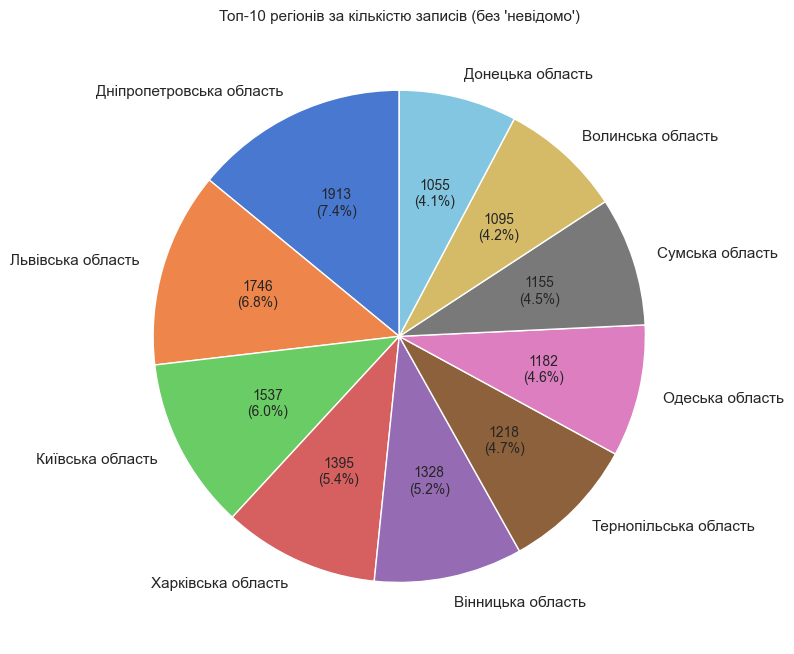

In [22]:
fig, ax = plt.subplots(figsize=(8, 8))

# прибираємо "(невідомо)"
df_regions = df[df["region_clean"] != "(невідомо)"]

# підрахунок
state_counts = df_regions["region_clean"].value_counts()

top10 = state_counts.head(10)
total = state_counts.sum()

def autopct_total_with_count(pct):
    absolute = pct / 100 * top10.sum()
    count = round(absolute)
    real_pct = absolute / total * 100
    return f"{count}\n({real_pct:.1f}%)"

ax.pie(
    top10,
    labels=top10.index,
    autopct=autopct_total_with_count,
    startangle=90
)

ax.set_title("Топ-10 регіонів за кількістю записів (без 'невідомо')")

plt.tight_layout()
plt.show()

C:\Users\ogelc\AppData\Local\Temp\ipykernel_4956\2990082457.py:22: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


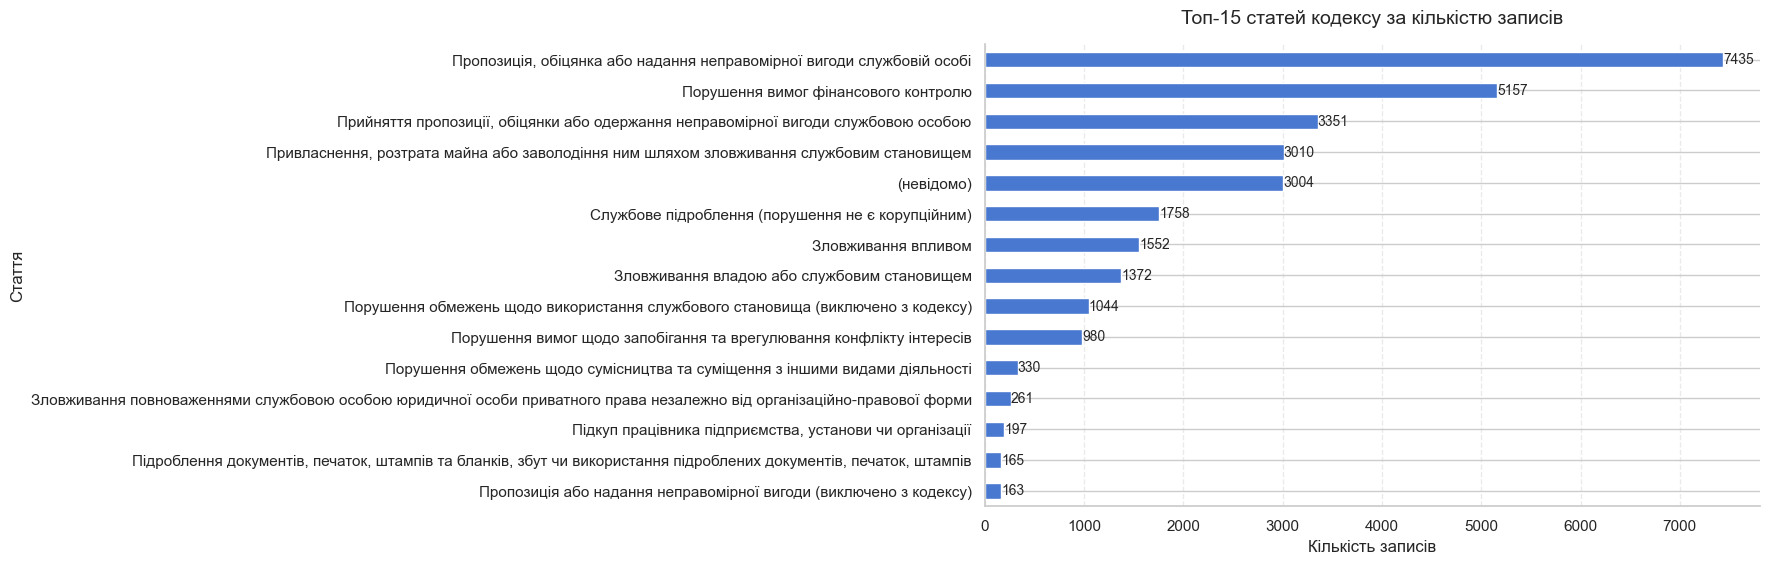

In [23]:
top_articles = article_counts.head(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))

top_articles.plot(kind="barh", ax=ax)

ax.set_title("Топ-15 статей кодексу за кількістю записів", fontsize=14, pad=15)
ax.set_xlabel("Кількість записів")
ax.set_ylabel("Стаття")

# сітка для кращого читання
ax.grid(axis="x", linestyle="--", alpha=0.4)

# прибираємо зайві рамки
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# підписи значень
for i, v in enumerate(top_articles):
    ax.text(v + 2, i, str(v), va="center")

plt.tight_layout()
plt.show()

## 5. Часові аспекти

Проаналізуємо динаміку у часі за датами постанов/вироків (`decreeDate`, `sentenceDate`).

Спочатку перетворимо їх у `datetime`.

In [24]:
for col in ["decreeDate", "sentenceDate", "punishmentStart"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df[["decreeDate", "sentenceDate", "punishmentStart"]].head()

,decreeDate,sentenceDate,punishmentStart
0,NaT,2019-02-25,2019-03-28
1,NaT,2012-06-12,2012-06-26
2,NaT,2011-10-31,2013-01-16
3,NaT,2011-10-17,2011-11-02
4,NaT,2011-11-10,2011-11-21


#### Перевірка коректності дат вироку та постанов

Нижче — перевірка типів, заповненості, діапазону та явних помилок (майбутні дати, дуже старі дати).

In [25]:
# Перевірка коректності дат
from datetime import datetime

for col in ["sentenceDate", "decreeDate", "punishmentStart"]:
    s = df[col]
    n_total = len(df)
    n_ok = s.notna().sum()
    n_nat = s.isna().sum()
    print(f"--- {col} ---")
    print(f"  Тип: {s.dtype}")
    print(f"  Заповнено: {n_ok:,} ({100*n_ok/n_total:.1f}%), порожні (NaT): {n_nat:,}")
    if n_ok > 0:
        valid = s.dropna()
        print(f"  Мін дата: {valid.min()}")
        print(f"  Макс дата: {valid.max()}")
        today = pd.Timestamp(datetime.now().date())
        future = (valid > today).sum()
        if future > 0:
            print(f"  Увага: дат у майбутньому: {future}")
        very_old = (valid.dt.year < 1990).sum()
        if very_old > 0:
            print(f"  Увага: дат раніше 1990: {very_old}")
    print()

# Зразок записів з заповненими датами
print("Зразок записів (дата вироку та постанови):")
sample = df[["sentenceDate", "decreeDate", "punishmentStart"]].dropna(subset=["sentenceDate"]).head(10)
display(sample)

--- sentenceDate ---
  Тип: datetime64[ns]
  Заповнено: 25,766 (89.7%), порожні (NaT): 2,947
  Мін дата: 1924-08-13 00:00:00
  Макс дата: 2026-02-13 00:00:00
  Увага: дат раніше 1990: 2

--- decreeDate ---
  Тип: datetime64[ns]
  Заповнено: 2,943 (10.2%), порожні (NaT): 25,770
  Мін дата: 2010-11-01 00:00:00
  Макс дата: 2026-03-05 00:00:00

--- punishmentStart ---
  Тип: datetime64[ns]
  Заповнено: 25,484 (88.8%), порожні (NaT): 3,229
  Мін дата: 2004-04-29 00:00:00
  Макс дата: 2026-02-24 00:00:00

Зразок записів (дата вироку та постанови):


,sentenceDate,decreeDate,punishmentStart
0,2019-02-25,NaT,2019-03-28
1,2012-06-12,NaT,2012-06-26
2,2011-10-31,NaT,2013-01-16
3,2011-10-17,NaT,2011-11-02
4,2011-11-10,NaT,2011-11-21
5,2015-12-28,NaT,2015-01-28
6,2012-03-14,NaT,2012-05-29
7,2011-12-26,NaT,2012-01-11
8,2011-07-29,NaT,2012-06-05
9,2012-03-01,NaT,2012-03-19


In [26]:
decree_by_year = df["decreeDate"].dt.year.value_counts().sort_index()
decree_by_year.index = decree_by_year.index.astype(int)

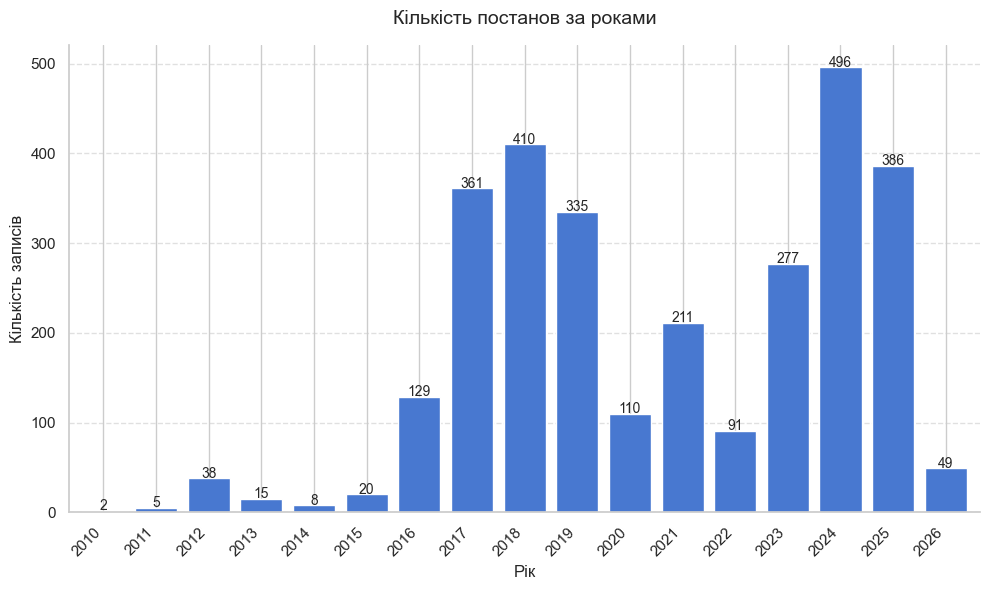

In [27]:

plt.figure(figsize=(10, 6))

ax = decree_by_year.plot(
    kind="bar",
    width=0.8
)

plt.title("Кількість постанов за роками", fontsize=14, pad=15)
plt.xlabel("Рік")
plt.ylabel("Кількість записів")

plt.xticks(rotation=45, ha="right")

# легка горизонтальна сітка
plt.grid(axis="y", linestyle="--", alpha=0.6)

# прибираємо верхню і праву рамку
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# підпис значень над стовпцями
for i, v in enumerate(decree_by_year):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

#### Динаміка кількості рішень по роках (лінійний графік)

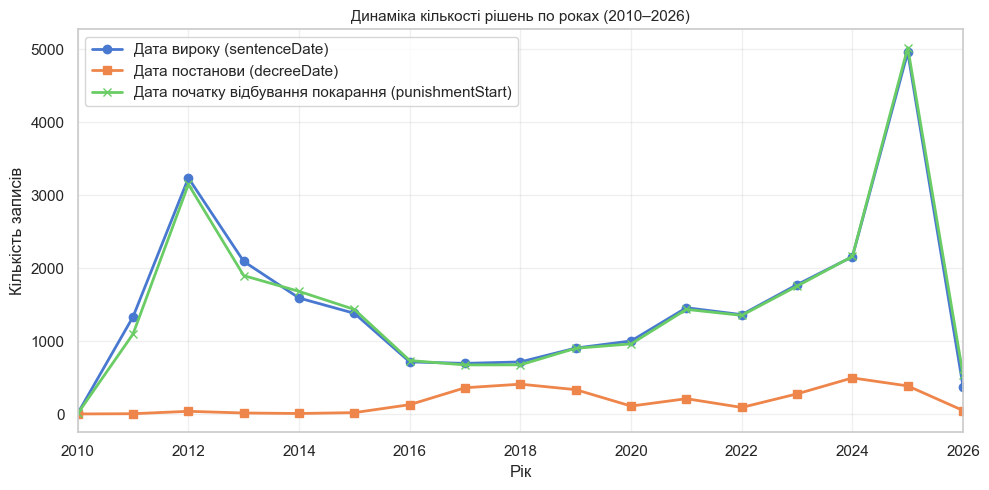

In [28]:
# Лінійний графік: кількість записів за роками (дата вироку та дата постанови), діапазон 2010–2026
sentence_by_year = df["sentenceDate"].dt.year.value_counts().sort_index()
decree_by_year = df["decreeDate"].dt.year.value_counts().sort_index()
punishmentStart_by_year = df["punishmentStart"].dt.year.value_counts().sort_index()
year_min, year_max = 2010, 2026
sentence_by_year = sentence_by_year.loc[(sentence_by_year.index >= year_min) & (sentence_by_year.index <= year_max)]
decree_by_year = decree_by_year.loc[(decree_by_year.index >= year_min) & (decree_by_year.index <= year_max)]
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sentence_by_year.index.astype(int), sentence_by_year.values, marker="o", label="Дата вироку (sentenceDate)", linewidth=2)
ax.plot(decree_by_year.index.astype(int), decree_by_year.values, marker="s", label="Дата постанови (decreeDate)", linewidth=2)
ax.plot(punishmentStart_by_year.index.astype(int), punishmentStart_by_year.values, marker="x", label="Дата початку відбування покарання (punishmentStart)", linewidth=2)
ax.set_xlim(year_min, year_max)
ax.set_xlabel("Рік")
ax.set_ylabel("Кількість записів")
ax.set_title("Динаміка кількості рішень по роках (2010–2026)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Крос-аналіз: регіон × вид покарання

Теплова карта та таблиця розподілу видів покарання по регіонах (топ-15 регіонів за кількістю записів).

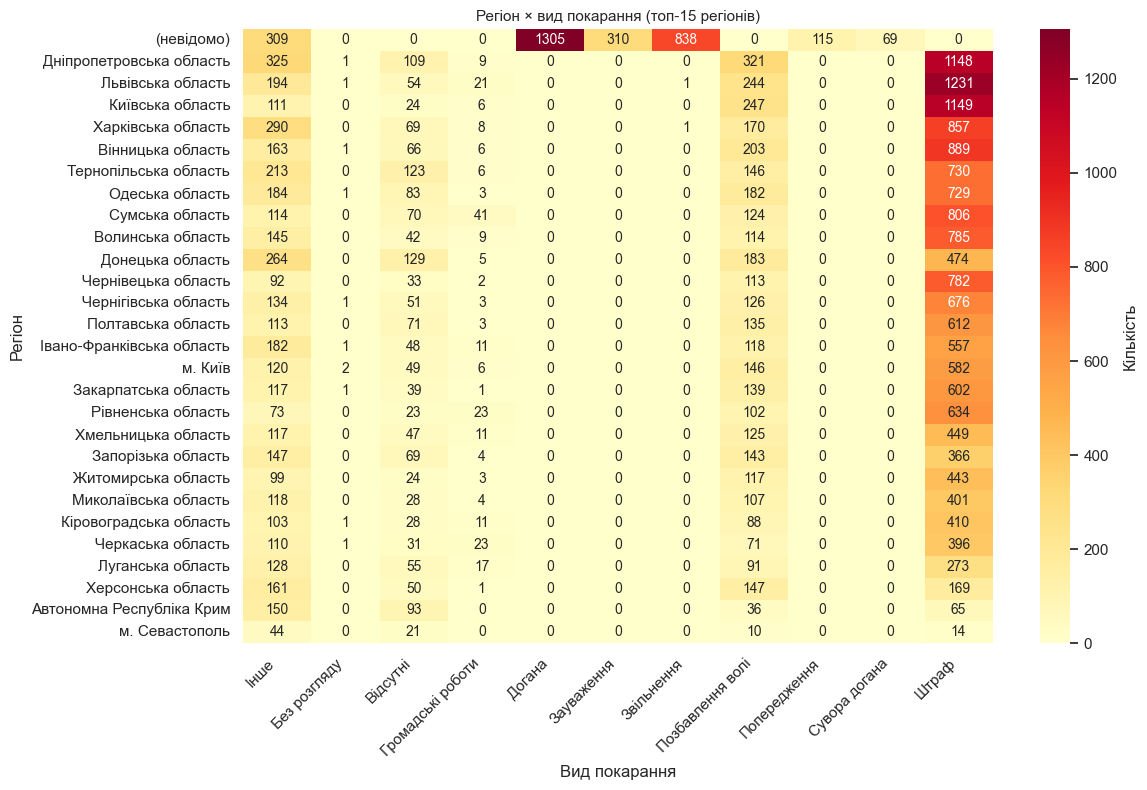

Фрагмент таблиці (топ-5 регіонів × усі види покарання):


punishment_status,Інше,Без розгляду,Відсутні,Громадські роботи,Догана,Зауваження,Звільнення,Позбавлення волі,Попередження,Сувора догана,Штраф
region_clean,,,,,,,,,,,
(невідомо),309,0,0,0,1305,310,838,0,115,69,0
Дніпропетровська область,325,1,109,9,0,0,0,321,0,0,1148
Львівська область,194,1,54,21,0,0,1,244,0,0,1231
Київська область,111,0,24,6,0,0,0,247,0,0,1149
Харківська область,290,0,69,8,0,0,1,170,0,0,857


In [29]:
# Таблиця спряженості: регіон × вид покарання (потрібні колонки з розділу 4)
missing = [c for c in ["region_clean", "punishment_status"] if c not in df.columns]
cross = pd.crosstab(df["region_clean"], df["punishment_status"])
top_regions = df["region_clean"].value_counts().head(40).index
cross_top = cross.reindex(top_regions).dropna(how="all").fillna(0).astype(int)
# Теплова карта
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(cross_top, annot=True, fmt="d", cmap="YlOrRd", ax=ax, cbar_kws={"label": "Кількість"})
ax.set_title("Регіон × вид покарання (топ-15 регіонів)")
ax.set_xlabel("Вид покарання")
ax.set_ylabel("Регіон")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
print("Фрагмент таблиці (топ-5 регіонів × усі види покарання):")
display(cross_top.head(5))